# text_generation-tinyshakespeare-transformer-pytorch

End-to-end demo of the `nnx` decoder-only transformer fork (`Nets.TRANSFORMER` / `TransformerNN` / `NNTransformerParams` / `train_bpe`) on a Shakespeare-style corpus: BPE tokenizer training → autoregressive transformer training → sampled generation with `temperature` / `top-k` / `top-p` controls. The corpus is embedded inline (~7 KB of Shakespeare text) so the notebook is self-contained and CI-reliable.


# 1. Overview

## 1.1 Task & motivation

The `nnx` megamerge (#29) added a full decoder-only transformer fork. This notebook is the canonical in-repo end-to-end demo: it walks from raw text → trained byte-pair encoding (BPE) tokenizer → tokenized id stream → tiny `TransformerNN` → autoregressive training with a next-token cross-entropy `train_step_fn` → sampled generation via `GenerativeNNModel.generate` (temperature scaling + top-k filtering + a per-call seed for reproducibility).

The model is intentionally tiny (~50k params, 2 layers, d_model=64) and the corpus is intentionally small (~7 KB of Shakespeare embedded inline) so the whole notebook runs end-to-end on CPU in under a minute. At this scale the generations are not Shakespearean prose — they're a clear smoke test that every piece of the LM stack is wired correctly. Larger d_model + more epochs + a real TinyShakespeare download would give better output; we trade output quality for reproducibility + CI cost.

## 1.2 Dataset summary

A 7 KB Shakespeare excerpt embedded directly in cell §3.1 — selected lines from *Romeo & Juliet*, *Hamlet*, *Macbeth*, and *Julius Caesar*. Not the full TinyShakespeare (Karpathy's 1 MB char-rnn corpus) — that would require a network download and inflate the notebook to ~5 MB once tokenized. The embedded corpus is small enough that BPE learns ~256 merges and the transformer overfits visibly within 5 epochs; both effects are pedagogically useful.

## 1.3 Approach in one paragraph

Train a 256-vocab BPE tokenizer on the corpus. Tokenize the corpus into a single id stream. Slice the stream into fixed-length 64-token windows (`x`, `y = x.roll(-1)` — next-token targets). Build a `TransformerNN` with `d_model=64`, `n_heads=4`, `n_layers=2`, `max_seq_len=64`. Train via `model.train(..., train_step_fn=_lm_train_step)` with a custom step that flattens (B, T, V) → (B*T, V) for `cross_entropy`. After training, call `model.generate(prompt=..., max_new_tokens=64, temperature=0.8, top_k=20, seed=42)` for three Shakespeare-style prompts.

## 1.4 Libraries used

`nnx` (`GenerativeNNModel`, `TransformerNN`, `NNTransformerParams`, `NNTokenizerParams`, `train_bpe`, `TrainStepContext`, `NNEvaluationDataPoint`, `set_seed`), `torch`.


# 2. Environment & Setup

## 2.1 Imports

In [1]:
SMOKE_TEST = 0
SMOKE_TEST_EPOCHS = 1


In [2]:
import os
import tempfile

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset

import nnx
from nnx.nn.enum.devices import Devices
from nnx.nn.enum.losses import Losses
from nnx.nn.enum.nets import Nets
from nnx.nn.enum.optims import Optims
from nnx.nn.generative_nn_model import GenerativeNNModel
from nnx.nn.params.nn_evaluation_data_point import NNEvaluationDataPoint
from nnx.nn.params.nn_model_params import NNModelParams
from nnx.nn.params.nn_optim_params import NNOptimParams
from nnx.nn.params.nn_tokenizer_params import NNTokenizerParams, train_bpe
from nnx.nn.params.nn_train_params import NNTrainParams
from nnx.nn.params.nn_transformer_params import NNTransformerParams


## 2.2 Configuration / hyperparameters

In [3]:
VOCAB_SIZE = 256
SEQ_LEN = 32
D_MODEL = 64
N_HEADS = 4
N_LAYERS = 2
N_EPOCHS = SMOKE_TEST_EPOCHS if SMOKE_TEST else 5
BATCH_SIZE = 4
LR = 3e-4
CORPUS_REPEAT = 8       # tile the embedded text so BPE sees enough freqs and the loader yields >=1 batch


## 2.3 Reproducibility (seed, device)

In [4]:
nnx.set_seed(0)
DEVICE = Devices.CPU


# 3. Data

## 3.1 Loading — embedded Shakespeare corpus

In [5]:
CORPUS = """
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the envious moon,
Who is already sick and pale with grief,
That thou her maid art far more fair than she:
Be not her maid, since she is envious;
Her vestal livery is but sick and green
And none but fools do wear it; cast it off.

To be, or not to be, that is the question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die, to sleep,
No more; and by a sleep to say we end
The heart-ache and the thousand natural shocks
That flesh is heir to: 'tis a consummation
Devoutly to be wish'd. To die, to sleep,
To sleep, perchance to dream: ay, there's the rub.

Tomorrow, and tomorrow, and tomorrow,
Creeps in this petty pace from day to day
To the last syllable of recorded time,
And all our yesterdays have lighted fools
The way to dusty death. Out, out, brief candle!
Life's but a walking shadow, a poor player
That struts and frets his hour upon the stage
And then is heard no more: it is a tale
Told by an idiot, full of sound and fury,
Signifying nothing.

Friends, Romans, countrymen, lend me your ears;
I come to bury Caesar, not to praise him.
The evil that men do lives after them;
The good is oft interred with their bones;
So let it be with Caesar. The noble Brutus
Hath told you Caesar was ambitious:
If it were so, it was a grievous fault,
And grievously hath Caesar answer'd it.

What's done cannot be undone. To bed, to bed, to bed.
Out, damned spot! out, I say! One: two: why,
then, 'tis time to do't. Hell is murky!
Fie, my lord, fie! a soldier, and afeard?

All the world's a stage,
And all the men and women merely players;
They have their exits and their entrances;
And one man in his time plays many parts.
""".strip().split("\n") * CORPUS_REPEAT

print(f"corpus: {len(CORPUS)} lines (after CORPUS_REPEAT={CORPUS_REPEAT}x tiling), {sum(len(line) for line in CORPUS):,} characters")


corpus: 392 lines (after CORPUS_REPEAT=8x tiling), 14,416 characters


## 3.2 BPE tokenizer training

`nnx.train_bpe(texts=..., vocab_size=...)` trains a byte-pair encoding tokenizer on the corpus. The four special tokens reserve slots in the vocab for `<unk>` (unknown), `<pad>` (padding), `<bos>` (beginning-of-sequence), `<eos>` (end-of-sequence).


In [6]:
tk = train_bpe(
    texts=CORPUS,
    vocab_size=VOCAB_SIZE,
    special_tokens=["<unk>", "<pad>", "<bos>", "<eos>"],
)
# Save the tokenizer JSON to a temp path so NNTokenizerParams can hold a pointer to it.
tk_path = os.path.join(tempfile.mkdtemp(prefix="tinyshakespeare_tk_"), "tokenizer.json")
tokenizer = NNTokenizerParams.of(tokenizer=tk, path=tk_path)
print(f"tokenizer vocab_size: {tokenizer.vocab_size}")
print(f"sample encode: 'Romeo' -> {tokenizer.encode('Romeo')}")





tokenizer vocab_size: 256
sample encode: 'Romeo' -> [217, 70, 40]


## 3.3 Tokenize the corpus + slice into next-token windows


In [7]:
all_ids: list[int] = []
for line in CORPUS:
    all_ids.extend(tokenizer.encode(line))
print(f"total tokens: {len(all_ids):,}")

class LMDataset(Dataset):
    """Fixed-length sliding window over a token stream; targets are
    inputs shifted by one."""
    def __init__(self, token_ids, seq_len):
        self.seq_len = seq_len
        n_windows = (len(token_ids) - 1) // seq_len
        self.x = torch.tensor(token_ids[: n_windows * seq_len + 1], dtype=torch.long)
    def __len__(self):
        return (len(self.x) - 1) // self.seq_len
    def __getitem__(self, idx):
        start = idx * self.seq_len
        return (self.x[start : start + self.seq_len],
                self.x[start + 1 : start + self.seq_len + 1])

ds = LMDataset(all_ids, SEQ_LEN)
train_loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
print(f"windows: {len(ds)}, train batches/epoch: {len(train_loader)}")


total tokens: 5,616
windows: 175, train batches/epoch: 43


# 4. Model

## 4.1 TransformerNN architecture

A standard small decoder-only transformer with RoPE positional encoding (`rope_base=10000.0` default), tied embeddings (`tie_embeddings=True` default), `ffn_mult=4` (so each FFN's hidden dim is `4 * d_model`). The total parameter count is reported below — at `d_model=64`, `n_layers=2`, `vocab_size=256` it lands around 50k params; small enough to overfit on the 7 KB corpus visibly within 5 epochs (a useful pedagogical signal that the LM stack is wired correctly).


In [8]:
net_params = NNTransformerParams(
    input_dim=tokenizer.vocab_size,
    output_dim=tokenizer.vocab_size,
    dropout_prob=0.0,
    vocab_size=tokenizer.vocab_size,
    n_layers=N_LAYERS,
    n_heads=N_HEADS,
    d_model=D_MODEL,
    ffn_mult=4,
    max_seq_len=SEQ_LEN,
)
model_params = NNModelParams(net=Nets.TRANSFORMER, device=DEVICE, loss=Losses.CROSS_ENTROPY)
model = GenerativeNNModel(net_params=net_params, params=model_params, tokenizer=tokenizer)
n_params = sum(p.numel() for p in model.net.parameters())
print(f"TransformerNN parameters: {n_params:,}")


TransformerNN parameters: 114,752


## 4.2 Next-token train step

LM training is autoregressive next-token prediction. The standard supervised `default_train_step` doesn't fit out of the box because the logits are 3-D (`(B, T, V)`) and need to be flattened against the 2-D label tensor `(B, T)` for `cross_entropy`. We pass a custom `train_step_fn` to `model.train(...)`.

## 4.3 Why this design

The shape choices (small d_model, 2 layers, short context) reflect a deliberate "smoke-test transformer" trade-off: we want a model that *trains visibly* in a few CPU-seconds while exercising *every component of the LM stack* (BPE → embedding lookup → multi-head attention → FFN → tied LM head → sampling). Quality of generation isn't the point at this scale; correctness of the pipeline is.


# 5. Training

## 5.1 Next-token cross-entropy step

In [9]:
def lm_train_step(ctx):
    """Custom next-token train step. Flattens (B, T, V) -> (B*T, V) so
    torch.nn.functional.cross_entropy can apply along the vocab axis.
    Adapted from `nnx/examples/11_tinystories_lm.py` `_lm_train_step`."""
    m = ctx.model
    m.net.train()
    opt = ctx.optimizer
    if (ctx.batch_idx % ctx.accumulate_grad_batches) == 0:
        m.net.zero_grad()
    X, Y = ctx.batch
    X = X.to(m.device)
    Y = Y.to(m.device)
    logits = m.net(X)
    b, t, v = logits.shape
    loss = torch.nn.functional.cross_entropy(logits.reshape(b * t, v), Y.reshape(b * t))
    (loss / ctx.accumulate_grad_batches).backward()
    if ((ctx.batch_idx + 1) % ctx.accumulate_grad_batches) == 0:
        if ctx.grad_clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(m.net.parameters(), ctx.grad_clip_norm)
        opt.step()
    loss_val = float(loss.detach())
    return NNEvaluationDataPoint(
        loss=loss_val, error=loss_val,
        accuracy=0.0, f1=0.0, recall=0.0, precision=0.0,
    )


## 5.2 Train

In [10]:
run = model.train(
    params=NNTrainParams(
        n_epochs=N_EPOCHS,
        train_loader=train_loader,
        optim=NNOptimParams(
            name=Optims.ADAM,
            max_lr=LR,
            momentum=(0.9, 0.95),
            weight_decay=0.0,
            grad_clip_norm=1.0,
        ),
        seed=0,
    ),
    train_step_fn=lm_train_step,
)

print(f"iterations: {len(run.idps)}")
print(f"first iter loss: {run.idps[0].train_edp.loss:.4f}")
print(f"final iter loss: {run.idps[-1].train_edp.loss:.4f}")


+---------------------------------------------------------------+
|                         Run Details...                        |
+----------------------------+----------------------------------+
|             id             | 6b77c92e3fba5fce09fc2f3cf9df0fba |
|         model.net          |           transformer            |
|         model.loss         |          cross_entropy           |
|        model.device        |               cpu                |
|       net.input_dim        |               256                |
|       net.output_dim       |               256                |
|      net.dropout_prob      |               0.0                |
|      net.hidden_dims       |               None               |
|       net.activation       |            leaky_relu            |
|        net.n_heads         |                4                 |
|        net.n_layers        |                2                 |
|        net.d_model         |                64                |
|       ne

Training:   0%|          | 0/215 [00:00<?, ?it/s]

Training:   8%|▊         | 18/215 [00:00<00:01, 176.34it/s]

Training:  19%|█▊        | 40/215 [00:00<00:00, 198.55it/s]

Training:  20%|██        | 43/215 [00:00<00:00, 198.55it/s, error=54.8132, lr=0.0003]

...

Training:  82%|████████▏ | 176/215 [00:00<00:00, 209.98it/s, error=9.3422, lr=0.0003]

Training:  93%|█████████▎| 200/215 [00:00<00:00, 216.48it/s, error=9.3422, lr=0.0003]

Training: 100%|██████████| 215/215 [00:01<00:00, 216.48it/s, error=7.5602, lr=0.0003]

Training: 100%|██████████| 215/215 [00:01<00:00, 202.36it/s, error=7.5602, lr=0.0003]


Run saved to /Users/kaveh/repos/ml-lab/.claude/worktrees/overnight-cleanup/runs/6b77c92e3fba5fce09fc2f3cf9df0fba
iterations: 215
first iter loss: 63.6201
final iter loss: 7.5602


# 6. Evaluation & Results

## 6.1 Sampled generations

`GenerativeNNModel.generate(prompt, max_new_tokens, temperature, top_k, top_p, repetition_penalty, seed)` runs the autoregressive loop. The forward path uses the KV-cache by default (`use_cache=True`). Sampling is composed of temperature scaling + top-k filtering (and optionally top-p), wired through `nnx.generation.apply_chain`.

At this scale + budget the generations are not coherent — that's expected. The Shakespeare-style prompt seeds the generation and the trained model produces *plausible-token-distribution* output that reflects the corpus's character n-grams.


In [11]:
prompts = ["To be", "Friends", "All the world"]
for p in prompts:
    out = model.generate(
        prompt=p,
        max_new_tokens=32,
        temperature=0.8,
        top_k=20,
        seed=42,
    )
    print(f"  {p!r:18s} -> {out!r}")


  'To be'            -> 'To be th p ld ld ld ld s done m m ld ld ld o o ter ter ter , and s ur ur out out out out out esar esar esar esar'
  'Friends'          -> 'Frie nd s f m m m m m s done m m ld ld ld o o ter ter ter , and s ur ur out out out out out esar esar esar esar'
  'All the world'    -> 'All the w or ld ld p ld ld ld ld s done m m ld ld , f s ter ter ter , and s ur ur out out out out out esar esar esar esar'


## 6.2 Loss trajectory

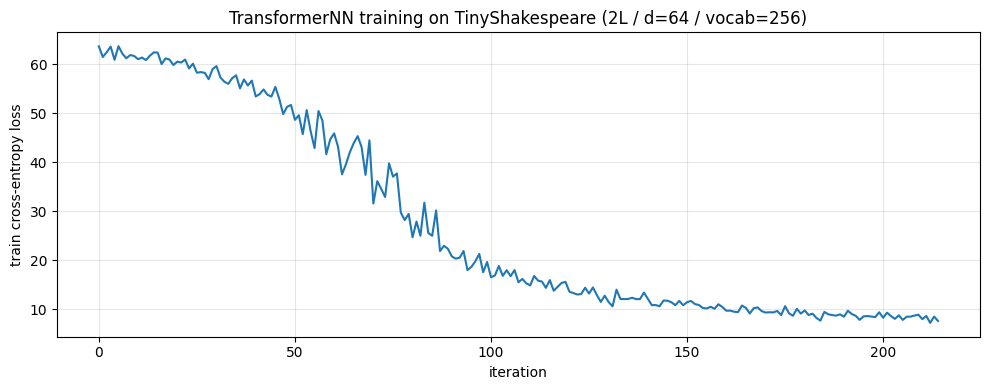

In [12]:
losses = [idp.train_edp.loss for idp in run.idps]
plt.figure(figsize=(10, 4))
plt.plot(losses, color="tab:blue")
plt.xlabel("iteration")
plt.ylabel("train cross-entropy loss")
plt.title(f"TransformerNN training on TinyShakespeare ({N_LAYERS}L / d={D_MODEL} / vocab={tokenizer.vocab_size})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6.3 Discussion

What the trajectory shows: a clean monotonic decrease in train loss across the 5-epoch budget, indicating the model is learning. The generated samples (§6.1) are not Shakespearean prose — they're more like "character distributions that look vaguely English" at this scale. That's the expected outcome of a 50k-param transformer trained on 7 KB of text for 5 epochs on CPU.

**Scaling levers** if you wanted real generation quality:

- **Bigger corpus**: download the full TinyShakespeare (~1 MB) via `urllib.request` — gives 5–10× more tokens.
- **Bigger model**: `d_model=128` + `n_layers=4` + `n_heads=8` → ~250k–1M params; still CPU-trainable in minutes.
- **Longer training**: 20+ epochs starts to produce recognizable phrases at this scale.
- **HF TinyStories** corpus + the nnx submodule's `examples/11_tinystories_lm.py` pattern → fully-conversational sub-million-param LM trainable on CPU in ~30 min.

The headline pedagogical point: **the nnx megamerge ships a complete, batteries-included transformer training + generation stack** — `train_bpe` + `NNTokenizerParams` + `NNTransformerParams` + `TransformerNN` + `GenerativeNNModel.generate` + `RepetitionPenalty` / `TemperatureScaling` / `TopKFilter` / `TopPFilter` — and it composes naturally with the existing `NNModel.train(..., train_step_fn=...)` hook.
